In [1]:
from __future__ import print_function


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.optimizers import RMSprop
from keras.layers import Conv2D, MaxPooling2D

In [2]:
import os
# Debe apuntar a la carpeta que CONTIENE las carpetas 'train', 'test' y 'val'.
# He eliminado el '.chest_xray' extra y el punto final.
main_path = r'C:\Users\Usuario\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray'

# 2. Usar os.path.join() para construir las rutas de forma segura. 
train_path = os.path.join(main_path, 'train')
val_path = os.path.join(main_path, 'val')
test_path = os.path.join(main_path, 'test')

# Ahora, cuando uses train_path en tu generador, la ruta será correcta.
# Por ejemplo: 'C:\...\chest_xray\train'
train_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    directory=train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle = True 
)

Found 5216 images belonging to 2 classes.


In [3]:
# Generador para la validación
test_val_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = test_val_datagen.flow_from_directory(
    directory=val_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Generador para la prueba
test_generator = test_val_datagen.flow_from_directory(
    directory=test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Usualmente no se barajan los datos de prueba
)

Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


--- Imágenes del Conjunto de Entrenamiento (al azar) ---


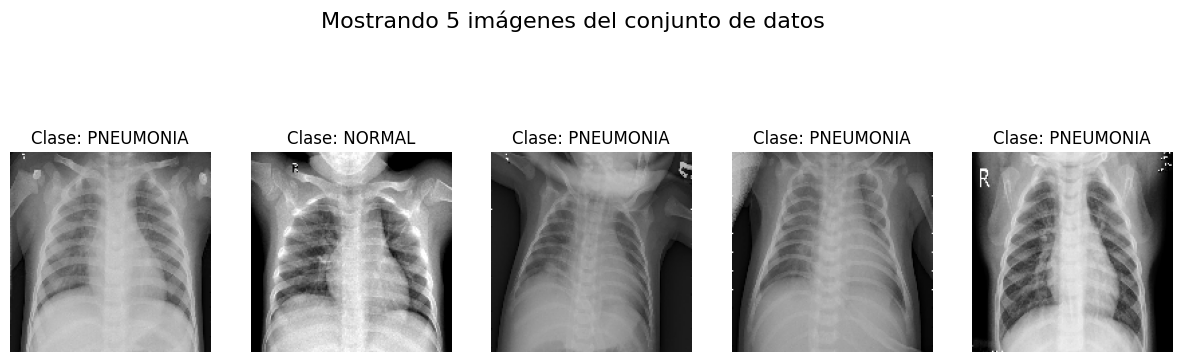


--- Imágenes del Conjunto de Validación ---


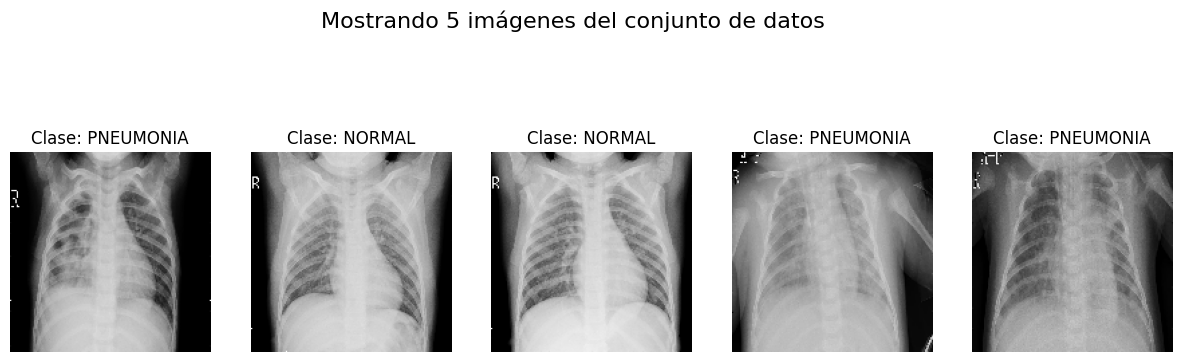


--- Imágenes del Conjunto de Prueba ---


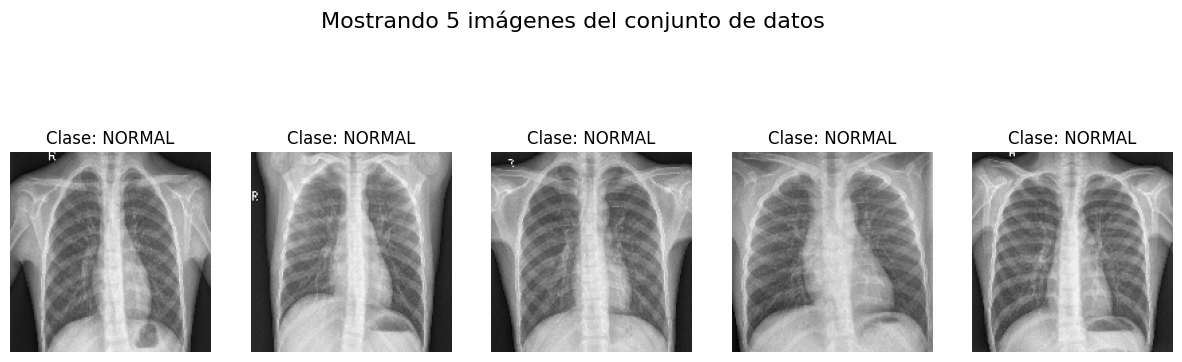

In [4]:
def plot_images_from_generator(generator, num_images=5):
    
    # Extraer un lote de imágenes y etiquetas del generador
    images, labels = next(generator)
    
    # Obtener el mapeo de las clases (ej. {'NORMAL': 0, 'PNEUMONIA': 1})
    # y lo invertimos para poder mostrar el nombre de la clase a partir del número
    class_labels = {v: k for k, v in generator.class_indices.items()}
    
    # Crear la figura para la visualización
    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Mostrando {num_images} imágenes del conjunto de datos", fontsize=16)
    
    # Iterar y mostrar las primeras 'num_images' imágenes del lote
    for i in range(num_images):
        ax = plt.subplot(1, num_images, i + 1)
        
        # Mostrar la imagen
        plt.imshow(images[i])
        
        # Obtener la etiqueta numérica (0 o 1) y encontrar su nombre
        label_index = int(labels[i])
        plt.title(f"Clase: {class_labels[label_index]}")
        
        # Ocultar los ejes
        plt.axis("off")
        
    plt.show()

# --- Visualizar 5 imágenes de cada generador ---

print("--- Imágenes del Conjunto de Entrenamiento (al azar) ---")
plot_images_from_generator(train_generator)

print("\n--- Imágenes del Conjunto de Validación ---")
plot_images_from_generator(validation_generator)

print("\n--- Imágenes del Conjunto de Prueba ---")
plot_images_from_generator(test_generator)

In [5]:
# Crear el objeto del modelo secuencial
model = Sequential()

# --- Bloque Convolucional 1 ---
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# --- Bloque Convolucional 2 ---
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# --- Bloque Convolucional 3 ---
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# --- Cabezal de Clasificación ---
# Aplanar los mapas de características 2D a un vector 1D
model.add(Flatten())

# Capa Densa para aprender combinaciones de características
model.add(Dense(512, activation='relu'))

# Capa de Salida para la clasificación binaria
model.add(Dense(1, activation='sigmoid'))

# Imprimir un resumen de la arquitectura
model.summary()
# 1. COMPILAR EL MODELO: Aquí definimos el optimizador, la pérdida y la métrica.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 2. ENTRENAR EL MODELO: Aquí definimos las épocas y pasamos los datos.
history = model.fit(
    train_generator,          # Generador de datos de entrenamiento
    validation_data=validation_generator, # Generador de datos de validación
    epochs=5,                 # Número de épocas que definimos
    verbose=1                 # Muestra una barra de progreso durante el entrenamiento
)

C:\Users\Usuario\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

C:\Users\Usuario\miniconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 603ms/step - accuracy: 0.8769 - loss: 0.3168 - val_accuracy: 0.8750 - val_loss: 0.3120
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 585ms/step - accuracy: 0.9609 - loss: 0.1150 - val_accuracy: 0.7500 - val_loss: 0.4913
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 575ms/step - accuracy: 0.9743 - loss: 0.0780 - val_accuracy: 0.6875 - val_loss: 0.5768
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 572ms/step - accuracy: 0.9785 - loss: 0.0592 - val_accuracy: 1.0000 - val_loss: 0.1000
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 572ms/step - accuracy: 0.9829 - loss: 0.0467 - val_accuracy: 0.9375 - val_loss: 0.0788


In [6]:
# --- Definición de la Arquitectura 1 ---
model_1 = Sequential(name="Modelo_1_C3D16")

# Capa Convolucional C3D16 con half-padding (padding='same')
model_1.add(Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(150, 150, 3)))

# Capa de Pooling
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Capa de Dropout para regularización
model_1.add(Dropout(0.5))

# Aplanar la red
model_1.add(Flatten())

# Capa de salida
model_1.add(Dense(1, activation='sigmoid'))

# Imprimir resumen del modelo
model_1.summary()

Model: "Modelo_1_C3D16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 150, 150, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 75, 75, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 75, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 90000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │          90,001 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 90,449 (353.32 KB)

 Trainable params: 90,449 (353.32 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compilar el modelo con la configuración acordada
model_1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Entrenar el modelo y guardar el historial de entrenamiento
history_1 = model_1.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    verbose=1
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 312ms/step - accuracy: 0.9007 - loss: 0.2436 - val_accuracy: 0.7500 - val_loss: 0.5189
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 308ms/step - accuracy: 0.9664 - loss: 0.0940 - val_accuracy: 0.6875 - val_loss: 0.6096
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 309ms/step - accuracy: 0.9768 - loss: 0.0717 - val_accuracy: 0.7500 - val_loss: 0.4732
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 307ms/step - accuracy: 0.9814 - loss: 0.0537 - val_accuracy: 0.8750 - val_loss: 0.1995
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 308ms/step - accuracy: 0.9864 - loss: 0.0439 - val_accuracy: 0.8750 - val_loss: 0.1591


In [8]:
from tensorflow.keras.layers import BatchNormalization

# --- Definición de la Arquitectura 2 ---
model_2 = Sequential(name="Modelo_2_2x_C3D16_BN")

# --- Bloque 1 ---
model_2.add(Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(150, 150, 3)))
model_2.add(BatchNormalization())

# --- Bloque 2 ---
model_2.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model_2.add(BatchNormalization())

# --- Capas de Reducción y Regularización ---
model_2.add(MaxPooling2D(pool_size=(2, 2)))
model_2.add(Dropout(0.5))

# --- Cabezal de Clasificación ---
model_2.add(Flatten())
model_2.add(Dense(1, activation='sigmoid'))

# Imprimir resumen del modelo
model_2.summary()

Model: "Modelo_2_2x_C3D16_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 150, 150, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 150, 150, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 150, 150, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 150, 150, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 75, 75, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 75, 75, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 90000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │          90,001 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 92,897 (362.88 KB)

 Trainable params: 92,833 (362.63 KB)

 Non-trainable params: 64 (256.00 B)

In [9]:
# Compilar el modelo con la misma configuración
model_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Entrenar el modelo y guardar el historial
history_2 = model_2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    verbose=1
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 479ms/step - accuracy: 0.9296 - loss: 0.8096 - val_accuracy: 0.8125 - val_loss: 0.7669
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 478ms/step - accuracy: 0.9674 - loss: 0.2404 - val_accuracy: 0.8750 - val_loss: 0.3747
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 478ms/step - accuracy: 0.9691 - loss: 0.2230 - val_accuracy: 0.6250 - val_loss: 3.1229
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 477ms/step - accuracy: 0.9820 - loss: 0.1583 - val_accuracy: 0.5000 - val_loss: 25.3234
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 480ms/step - accuracy: 0.9787 - loss: 0.1775 - val_accuracy: 0.8750 - val_loss: 1.5277


In [11]:
import pandas as pd
def load_image_paths(data_path):
    
    image_data = []
    # Las etiquetas son los nombres de las subcarpetas (ej. PNEUMONIA, NORMAL)
    labels = os.listdir(data_path)

    for label in labels:
        label_path = os.path.join(data_path, label)
        # Nos aseguramos de que es un directorio
        if os.path.isdir(label_path):
            # Obtenemos la lista de todas las imágenes en la carpeta de la etiqueta
            image_files = os.listdir(label_path)
            for image_file in image_files:
                # Generamos la ruta completa de la imagen
                full_path = os.path.join(label_path, image_file)
                # Agregamos la ruta y la etiqueta a nuestra lista
                image_data.append([full_path, label])

    return image_data
train_data = load_image_paths(train_path)
train_df = pd.DataFrame(train_data, columns=['filepath', 'label'])

In [13]:
from sklearn.utils.class_weight import compute_class_weight
# Ver la distribución de clases
print("Distribución de clases en el conjunto de entrenamiento:")
print(train_df['label'].value_counts())

# Calcular los pesos de clase para balancear el entrenamiento
# Esto le dará más importancia a la clase 'NORMAL' que tiene menos muestras
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

# Keras espera un diccionario que mapee el índice de la clase a su peso
# El generador de datos asigna los índices alfabéticamente: NORMAL -> 0, PNEUMONIA -> 1
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nPesos de clase calculados: {class_weights_dict}")

Distribución de clases en el conjunto de entrenamiento:
label
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64

Pesos de clase calculados: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [14]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Aseguramos que la función para cargar las rutas esté definida
def load_image_paths(data_path):
    image_data = []
    labels = os.listdir(data_path)
    for label in labels:
        label_path = os.path.join(data_path, label)
        if os.path.isdir(label_path):
            image_files = os.listdir(label_path)
            for image_file in image_files:
                full_path = os.path.join(label_path, image_file)
                image_data.append([full_path, label])
    return image_data

# Se crean los DataFrames para cada conjunto de datos
train_df = pd.DataFrame(load_image_paths(train_path), columns=['filepath', 'label'])
val_df = pd.DataFrame(load_image_paths(val_path), columns=['filepath', 'label'])
test_df = pd.DataFrame(load_image_paths(test_path), columns=['filepath', 'label'])


# Usamos la función de preprocesamiento específica de MobileNetV2
datagen_mobilenet = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_mobilenet = datagen_mobilenet.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

validation_generator_mobilenet = datagen_mobilenet.flow_from_dataframe(
    dataframe=val_df,  # <--- Ahora val_df ya existe
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 validated image filenames belonging to 2 classes.
Found 16 validated image filenames belonging to 2 classes.


In [15]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Creamos un nuevo generador que usa la función de preprocesamiento de MobileNetV2
# NOTA: No usamos rescale=1./255, sino la función específica del modelo.
datagen_mobilenet = ImageDataGenerator(preprocessing_function=preprocess_input)

#Creamos los nuevos generadores con el tamaño de imagen correcto (224x224)
print("Generador de Entrenamiento (MobileNetV2):")
train_generator_mobilenet = datagen_mobilenet.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

print("\nGenerador de Validación (MobileNetV2):")
validation_generator_mobilenet = datagen_mobilenet.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Generador de Entrenamiento (MobileNetV2):
Found 5216 validated image filenames belonging to 2 classes.

Generador de Validación (MobileNetV2):
Found 16 validated image filenames belonging to 2 classes.


In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Cargar el Modelo Base (MobileNetV2)
# weights='imagenet': Carga los pesos aprendidos en la base de datos ImageNet.
# include_top=False: Descarta la capa de clasificación original de 1000 clases.
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Esto es crucial: le decimos a Keras que no modifique los pesos ya aprendidos por MobileNetV2.
base_model.trainable = False

# Tomamos la salida del modelo base y construimos sobre ella.
x = base_model.output
# GlobalAveragePooling2D es una capa moderna y eficiente para reducir las dimensiones.
x = GlobalAveragePooling2D()(x)
# Agregamos una capa densa para que nuestro modelo pueda aprender patrones complejos.
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # Capa de Dropout para evitar el sobreajuste.
# La capa de salida final para nuestra clasificación binaria.
predictions = Dense(1, activation='sigmoid')(x)

# Este modelo une el extractor de características (base_model) con nuestro nuevo clasificador (predictions).
model_3 = Model(inputs=base_model.input, outputs=predictions, name="Modelo_3_MobileNetV2")

# Imprimir el resumen del modelo.
model_3.summary()

Model: "Modelo_3_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Asegúrate de que 'train_df' existe (lo creaste en el paso anterior)
print("Distribución de clases en el conjunto de entrenamiento:")
print(train_df['label'].value_counts())

# Calcular los pesos de clase para balancear el entrenamiento
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

# Crear el diccionario que Keras espera
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nPesos de clase calculados y listos para usar: {class_weights_dict}")

Distribución de clases en el conjunto de entrenamiento:
label
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64

Pesos de clase calculados y listos para usar: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [18]:
# Compilar el modelo con la configuración ya definida
model_3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Entrenar el modelo por 5 épocas
history_3 = model_3.fit(
    train_generator_mobilenet,
    validation_data=validation_generator_mobilenet,
    epochs=5,
    class_weight=class_weights_dict, # <-- ¡Aquí aplicamos los pesos para balancear las clases!
    verbose=1
)

C:\Users\Usuario\miniconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 628ms/step - accuracy: 0.9294 - loss: 0.1720 - val_accuracy: 0.8750 - val_loss: 0.2369
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 617ms/step - accuracy: 0.9634 - loss: 0.1000 - val_accuracy: 0.9375 - val_loss: 0.1613
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 621ms/step - accuracy: 0.9728 - loss: 0.0776 - val_accuracy: 0.8750 - val_loss: 0.1066
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 622ms/step - accuracy: 0.9749 - loss: 0.0652 - val_accuracy: 0.8750 - val_loss: 0.1148
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 620ms/step - accuracy: 0.9766 - loss: 0.0565 - val_accuracy: 1.0000 - val_loss: 0.0912


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [20]:
# Crearemos el generador de prueba para MobileNetV2 (224x224)
datagen_mobilenet_test = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator_mobilenet = datagen_mobilenet_test.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Función para graficar la matriz de confusión
def plot_confusion_matrix(cm, class_names, title):
    """Función para graficar una matriz de confusión."""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')
    plt.show()

# Obtener las etiquetas verdaderas y los nombres de las clases
# (El generador debe tener shuffle=False para que esto funcione correctamente)
true_labels_150 = test_generator.classes
true_labels_224 = test_generator_mobilenet.classes
class_labels = list(test_generator.class_indices.keys())

Found 624 validated image filenames belonging to 2 classes.
